<a href="https://colab.research.google.com/github/lekkalapudiswetha-work/ML-Project/blob/main/stock_ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Stock Market Ensemble Forecasting Project

Baseline Pipeline (XGBoost + Feature Engineering)

In [1]:
!pip install yfinance xgboost ta scikit-learn matplotlib pandas numpy

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=77a0f76b6bc8bed9dca5170d20fa1eb794e3a95867b826a24f5ba2e284fec8c7
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ta.momentum import RSIIndicator

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [31]:
#Download Stock Data

import yfinance as yf
import pandas as pd

df = yf.download(
    "SPY",
    start="2013-01-01",
    end="2024-01-01"
)

print(df.shape)
df.head()

/tmp/ipykernel_5266/2844690623.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed

(2768, 5)


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2013-01-02,116.291740,116.363395,115.232804,115.535361,192059000
2013-01-03,116.028954,116.538515,115.718439,116.235971,144761800
2013-01-04,116.538513,116.729603,115.981182,116.220042,116817700
2013-01-07,116.220024,116.331490,115.790074,116.124485,110002500
2013-01-08,115.885681,116.172311,115.431846,116.013075,121265100


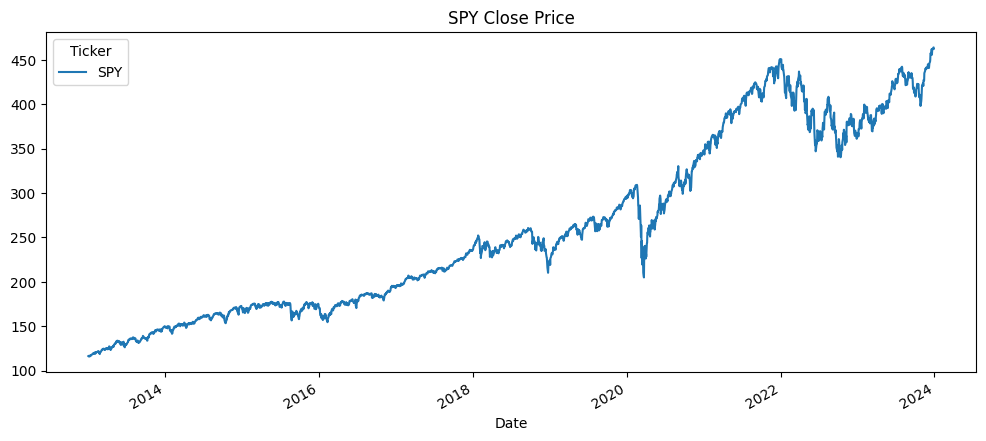

In [33]:
#Basic Visualization

df['Close'].plot(
    figsize=(12,5),
    title=f'{ticker} Close Price'
)
plt.show()

In [54]:
#Returns and Prediction Target

print(df.columns)
df.columns = [
col[0] if isinstance(col, tuple) else col
for col in df.columns
]
print(df.columns)

df["returns"] = df["Close"].pct_change()

df["target"]=(
df["Close"].shift(-5) >
df["Close"]
).astype(int)

df[['Close','returns','target']].head(10)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'target', 'ma5',
       'ma20', 'trend_signal', 'vol5', 'vol10', 'rsi', 'vol_ma10', 'lag_1',
       'lag_2', 'lag_3', 'lag_4', 'lag_5'],
      dtype='object')
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'target', 'ma5',
       'ma20', 'trend_signal', 'vol5', 'vol10', 'rsi', 'vol_ma10', 'lag_1',
       'lag_2', 'lag_3', 'lag_4', 'lag_5'],
      dtype='object')


,Close,returns,target
Date,,,
2013-01-30,119.484489,NaN,1
2013-01-31,119.189880,-0.002466,1
2013-02-01,120.415985,0.010287,1
2013-02-04,119.062508,-0.011240,1
2013-02-05,120.264702,0.010097,1
2013-02-06,120.352280,0.000728,1
2013-02-07,120.193069,-0.001323,1
2013-02-08,120.861877,0.005564,1
2013-02-11,120.837967,-0.000198,1


In [55]:
##Feature Engineering
#Trend Features

df['ma5']=df['Close'].rolling(5).mean()
df['ma20']=df['Close'].rolling(20).mean()

df['trend_signal']=(
    df['ma5']-df['ma20']
)

In [57]:
#Volatility Features

df['vol5']=(
    df['returns'].rolling(5).std()
)

df['vol10']=(
    df['returns'].rolling(10).std()
)

In [58]:
#Momentum (RSI)

close = df['Close'].astype(float).squeeze()

df['rsi']=RSIIndicator(close).rsi()

In [59]:
#Volume Context

df['vol_ma10']=(
    df['Volume'].rolling(10).mean()
)

In [60]:
#Lag Features

for lag in range(1,6):
    df[f'lag_{lag}']=df['returns'].shift(lag)

In [61]:
#Final Feature Set

features=[
    'trend_signal',
    'vol5',
    'vol10',
    'rsi',
    'vol_ma10',
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_4',
    'lag_5'
]


df=df.dropna()

print(df.shape)

(2730, 19)


In [62]:
#Time-Based Split (No Leakage)

df.index = pd.to_datetime(df.index)

train = df[df.index < '2022-01-01']

val = df[
    (df.index >= '2022-01-01') &
    (df.index < '2023-01-01')
]

test = df[df.index >= '2023-01-01']

print(
len(train),
len(val),
len(test)
)

2229 251 250


In [63]:
print(df.shape)

(2730, 19)


In [65]:
from xgboost import XGBClassifier


features = [
"trend_signal",
"vol10",
"rsi",
"lag_1",
"lag_2",
"lag_3",
"lag_4",
"lag_5"
]

neg = (train["target"]==0).sum()
pos = (train["target"]==1).sum()

print(neg,pos)

weight = neg/pos

model = XGBClassifier(
n_estimators=300,
max_depth=4,
learning_rate=.03,
scale_pos_weight=weight
)

model.fit(
train[features],
train["target"]
)

831 1398


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [66]:
from sklearn.metrics import accuracy_score

val_pred = model.predict(
val[features]
)

print(
"Validation Accuracy:",
accuracy_score(
val["target"],
val_pred
)
)

Validation Accuracy: 0.5298804780876494


In [70]:
baseline = val["target"].mean()

print(
"Always predict UP baseline:",
baseline
)

Always predict UP baseline: 0.46613545816733065


In [71]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    val["target"],
    val_pred
)

print(cm)

[[57 77]
 [41 76]]


In [72]:
from sklearn.metrics import classification_report

print(
classification_report(
val["target"],
val_pred
))

              precision    recall  f1-score   support

           0       0.58      0.43      0.49       134
           1       0.50      0.65      0.56       117

    accuracy                           0.53       251
   macro avg       0.54      0.54      0.53       251
weighted avg       0.54      0.53      0.52       251



vol10           0.162297
rsi             0.143324
trend_signal    0.125784
lag_1           0.119060
lag_5           0.118542
lag_2           0.113581
lag_3           0.109823
lag_4           0.107590
dtype: float32


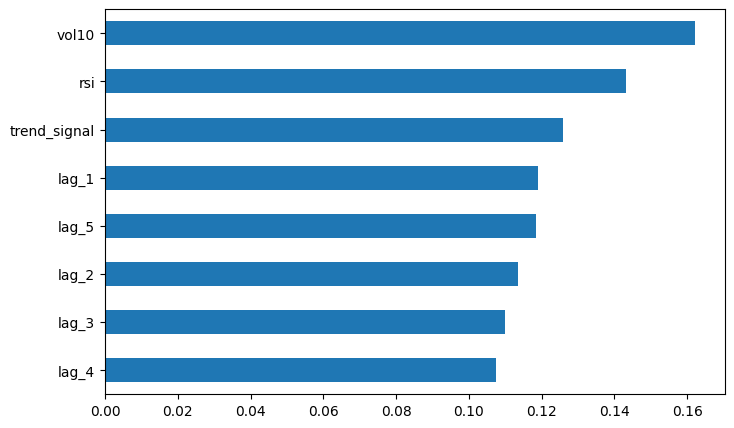

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
model.feature_importances_,
index=features
).sort_values()

print(
importance.sort_values(
ascending=False
)
)

importance.plot(
kind="barh",
figsize=(8,5)
)

plt.show()

In [74]:
probs = model.predict_proba(
val[features]
)[:,1]

for t in [0.4,0.45,0.5,0.55,0.6]:

    pred=(probs>t).astype(int)

    acc=(pred==val["target"]).mean()

    print(
        t,
        acc
    )

0.4 0.4581673306772908
0.45 0.47410358565737054
0.5 0.5298804780876494
0.55 0.5099601593625498
0.6 0.5179282868525896


In [75]:
test_pred = model.predict(
test[features]
)

print(
"Test Accuracy:",
accuracy_score(
test["target"],
test_pred
))

Test Accuracy: 0.544


In [77]:
val.loc[:, "xgb_pred"] = val_pred
test.loc[:, "xgb_pred"] = test_pred

In [78]:
val = val.copy()
test = test.copy()

val["xgb_prob"] = model.predict_proba(
val[features]
)[:,1]

test["xgb_prob"] = model.predict_proba(
test[features]
)[:,1]

**ARIMAX**

In [91]:
#ARIMAX target

df["future_return"] = (
df["Close"].shift(-5)/df["Close"] - 1
)

df["target"]=(
df["Close"].shift(-5) >
df["Close"]
).astype(int)

df=df.dropna()

In [92]:
train = df[df.index < '2022-01-01'].copy()

val = df[
(df.index >= '2022-01-01') &
(df.index < '2023-01-01')
].copy()

In [93]:
exog_features = [
"trend_signal",
"vol10",
"rsi"
]

In [102]:
#Fit ARIMAX

from statsmodels.tsa.statespace.sarimax import SARIMAX

model_arimax = SARIMAX(
train["future_return"],
exog=train[exog_features],
order=(1,1,1),
enforce_stationarity=False,
enforce_invertibility=False
)

fit_arimax=model_arimax.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [103]:
#Predict Validation

forecast=fit_arimax.get_forecast(
steps=len(val),
exog=val[exog_features]
)

arimax_pred=forecast.predicted_mean

arimax_dir=(arimax_pred>0).astype(int)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [104]:
#Evaluate

from sklearn.metrics import accuracy_score

print(
accuracy_score(
val["target"],
arimax_dir
))

0.47808764940239046


In [107]:
print(fit_arimax.model.order)

(1, 1, 1)


In [108]:
print(fit_arimax.aic)

-13623.592262612481


**LSTM**

In [109]:
seq_features = [
"trend_signal",
"vol10",
"rsi",
"lag_1",
"lag_2",
"lag_3",
"lag_4",
"lag_5"
]

In [110]:
#scale inputs

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled = scaler.fit_transform(
df[seq_features]
)

In [111]:
import numpy as np

window=20

X=[]
y=[]

targets=df["target"].values

for i in range(window,len(df)):

    X.append(
        scaled[i-window:i]
    )

    y.append(
        targets[i]
    )

X=np.array(X)
y=np.array(y)

print(X.shape)

(2700, 20, 8)


In [112]:
#time split

n=len(X)

train_end=int(.7*n)
val_end=int(.85*n)

X_train=X[:train_end]
X_val=X[train_end:val_end]
X_test=X[val_end:]

y_train=y[:train_end]
y_val=y[train_end:val_end]
y_test=y[val_end:]

print(X_train.shape)

(1889, 20, 8)


In [113]:
import tensorflow as tf

In [114]:
model_lstm = tf.keras.Sequential([

tf.keras.layers.LSTM(
32,
return_sequences=False
),

tf.keras.layers.Dropout(.2),

tf.keras.layers.Dense(
1,
activation='sigmoid'
)

])

In [115]:
model_lstm.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [116]:
history = model_lstm.fit(
X_train,
y_train,
epochs=20,
batch_size=32,
validation_data=(
X_val,
y_val
),
verbose=1
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6077 - loss: 0.6699 - val_accuracy: 0.5961 - val_loss: 0.6751
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6220 - loss: 0.6648 - val_accuracy: 0.5961 - val_loss: 0.6794
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6220 - loss: 0.6660 - val_accuracy: 0.5961 - val_loss: 0.6763
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6220 - loss: 0.6623 - val_accuracy: 0.5961 - val_loss: 0.6764
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6220 - loss: 0.6638 - val_accuracy: 0.5961 - val_loss: 0.6803
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6220 - loss: 0.6661 - val_accuracy: 0.5961 - val_loss: 0.6747
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6220 - loss: 0.6618 - val_accuracy: 0.5961 - val_loss: 0.6764
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6220 - loss: 0.6631 - val_accuracy: 0.5961 - va

In [117]:
loss,acc = model_lstm.evaluate(
X_val,
y_val
)

print(
"LSTM accuracy:",
acc
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5961 - loss: 0.6775
LSTM accuracy: 0.5960590839385986


In [118]:
lstm_probs = model_lstm.predict(
X_val
).flatten()

lstm_pred = (
lstm_probs>.5
).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [119]:
from sklearn.metrics import accuracy_score

print(
accuracy_score(
y_val,
lstm_pred
))

0.5960591133004927


In [123]:
!pwd
!ls
!git clone https://github.com/lekkalapudiswetha-work/ML-Project.git


/content
sample_data
Cloning into 'ML-Project'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 27 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 10.11 KiB | 2.53 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [124]:
%cd ML-Project

/content/ML-Project


In [125]:
!git config --global user.name "Swetha"
!git config --global user.email "lekkalapudiswetha.work@gmail.com"

In [126]:
!git add .
!git commit -m "Implemented XGBoost ARIMAX and LSTM baselines"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [128]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address
